Segment the Data —Scale the features, then apply K-Means (use the elbow method to pick k) and DBSCAN to the same data, and compare the groupings they produce. Use PCA to reduce the data to 2 dimensions and visualize the clusters from both algorithms on a scatter plot.

Deliverables
Notebook with scaling, elbow-method plot, K-Means and DBSCAN clustering
* PCA-reduced 2D scatter plots colored by cluster for both algorithms
* 3–4 sentences describing what each cluster represents

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [ ]:
# load the dataset

df = pd.read_csv("wine-clustering.csv")
X = df.copy()

print(f'Dataset Shape: {X.shape[0]} rows, {X.shape[1]} columns')
display(X.head())

Dataset Shape: 178 rows, 13 columns


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
summary = pd.DataFrame({
    'dtype': X.dtypes.astype(str),
    'missing': X.isnull().sum(),
    'min': X.min(),
    'max': X.max(),
    'mean': X.mean(),
    'std': X.std()
})
display(summary.round(3))

,dtype,missing,min,max,mean,std
Alcohol,float64,0,11.03,14.83,13.001,0.812
Malic_Acid,float64,0,0.74,5.80,2.336,1.117
Ash,float64,0,1.36,3.23,2.367,0.274
Ash_Alcanity,float64,0,10.60,30.00,19.495,3.340
Magnesium,int64,0,70.00,162.00,99.742,14.282
Total_Phenols,float64,0,0.98,3.88,2.295,0.626
Flavanoids,float64,0,0.34,5.08,2.029,0.999
Nonflavanoid_Phenols,float64,0,0.13,0.66,0.362,0.124
Proanthocyanins,float64,0,0.41,3.58,1.591,0.572
Color_Intensity,float64,0,1.28,13.00,5.058,2.318


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

display(scaled_df.head().round(3))
print('Scaled feature means (first 5):', np.round(X_scaled.mean(axis=0)[:5], 3))
print('Scaled feature stds (first 5): ', np.round(X_scaled.std(axis=0)[:5], 3))

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.519,-0.562,0.232,-1.170,1.914,0.809,1.035,-0.660,1.225,0.252,0.362,1.848,1.013
1,0.246,-0.499,-0.828,-2.491,0.018,0.569,0.734,-0.821,-0.545,-0.293,0.406,1.113,0.965
2,0.197,0.021,1.109,-0.269,0.088,0.809,1.216,-0.498,2.136,0.269,0.318,0.789,1.395
3,1.692,-0.347,0.488,-0.809,0.931,2.491,1.467,-0.982,1.032,1.186,-0.428,1.184,2.335
4,0.296,0.228,1.840,0.452,1.282,0.809,0.663,0.227,0.401,-0.319,0.362,0.450,-0.038


Scaled feature means (first 5): [-0. -0. -0. -0. -0.]
Scaled feature stds (first 5):  [1. 1. 1. 1. 1.]


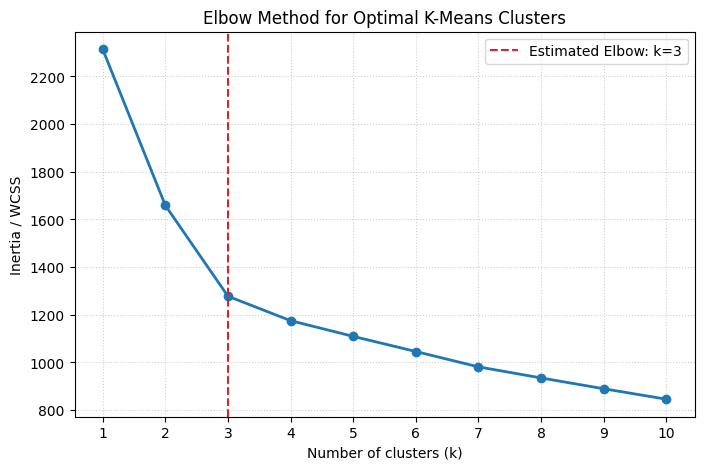

Selected optimal k via Elbow method: k = 3


In [ ]:
k_values = list(range(1, 11))
inertias = []

for k in k_values:
  model = KMeans(n_clusters=k, random_state=42, n_init=10)
  model.fit(X_scaled)
  inertias.append(model.inertia_)

points = np.column_stack([k_values, inertias]).astype(float)
first, last = points[0], points[-1]
line_vec = last - first
line_unit = line_vec / np.linalg.norm(line_vec)
vec_from_first = points - first
projection = np.outer(vec_from_first @ line_unit, line_unit)
perpendicular = vec_from_first - projection
distances = np.linalg.norm(perpendicular, axis=1)

distances[0] = -np.inf
distances[-1] = -np.inf
elbow_k = int(points[np.argmax(distances), 0])

# plotting the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', linewidth=2, color='#1f77b4')
plt.axvline(
    elbow_k,
    linestyle='--',
    color='#d62728',
    label=f'Estimated Elbow: k={elbow_k}',
)
plt.xticks(k_values)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia / WCSS')
plt.title('Elbow Method for Optimal K-Means Clusters')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f'Selected optimal k via Elbow method: k = {elbow_k}')

In [ ]:
# Fitting KMeans model

kmeans = KMeans(n_clusters=elbow_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print('K-Means Cluster Counts:')
display(
    pd.Series(kmeans_labels, name='Count')
    .value_counts()
    .sort_index()
    .to_frame()
)

K-Means Cluster Counts:


,count
Count,
0,65
1,51
2,62


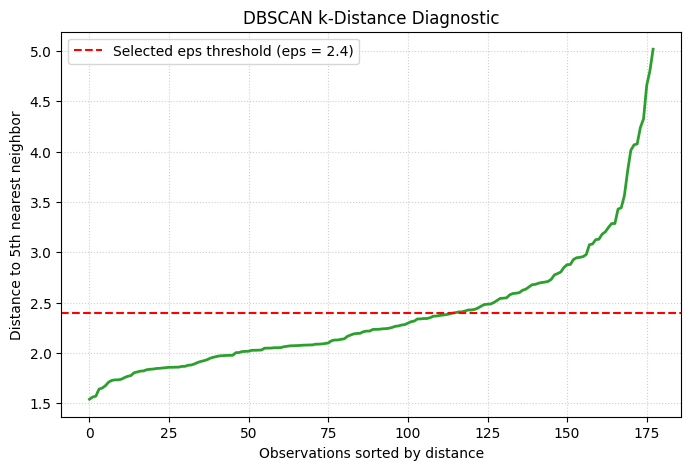

Reference Distance Percentiles:
70th percentile: 2.479
75th percentile: 2.587
80th percentile: 2.696
85th percentile: 2.878
90th percentile: 3.127
95th percentile: 3.602


In [ ]:
# Determining optimal eps using a k-NN distance graph (min_samples = 5)
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances_nn, _ = neighbors.kneighbors(X_scaled)

k_distances = np.sort(distances_nn[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, color='#2ca02c', linewidth=2)
plt.axhline(
    2.4,
    linestyle='--',
    color='red',
    label='Selected eps threshold (eps = 2.4)',
)
plt.xlabel('Observations sorted by distance')
plt.ylabel(f'Distance to {min_samples}th nearest neighbor')
plt.title('DBSCAN k-Distance Diagnostic')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print('Reference Distance Percentiles:')
for p in [70, 75, 80, 85, 90, 95]:
  print(f'{p}th percentile: {np.percentile(k_distances, p):.3f}')

In [ ]:
# Fit DBSCAN model
eps = 2.4
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int(np.sum(dbscan_labels == -1))

print(f'DBSCAN clusters (excluding noise): {n_dbscan_clusters}')
print(
    f'Noise points: {n_noise} of {len(dbscan_labels)}'
    f' ({n_noise / len(dbscan_labels):.1%})\n'
)
print('DBSCAN Label Counts (-1 indicates noise):')
display(
    pd.Series(dbscan_labels, name='Count').value_counts().sort_index().to_frame()
)

DBSCAN clusters (excluding noise): 2
Noise points: 36 of 178 (20.2%)

DBSCAN Label Counts (-1 indicates noise):


,count
Count,
-1,36
0,99
1,43


In [ ]:
# Cross-Tabulation Comparison

comparison = pd.DataFrame(
    {'KMeans_Cluster': kmeans_labels, 'DBSCAN_Cluster': dbscan_labels}
)

print('Cross-tabulation of K-Means vs DBSCAN assignments:')
display(
    pd.crosstab(
        comparison['KMeans_Cluster'],
        comparison['DBSCAN_Cluster'],
        margins=True,
    )
)

Cross-tabulation of K-Means vs DBSCAN assignments:


DBSCAN_Cluster,-1,0,1,All
KMeans_Cluster,,,,
0,23,42,0,65
1,8,0,43,51
2,5,57,0,62
All,36,99,43,178


In [ ]:
# Quantitative Clustering Metrics

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)

non_noise = dbscan_labels != -1
dbscan_sil = (
    silhouette_score(X_scaled[non_noise], dbscan_labels[non_noise])
    if len(np.unique(dbscan_labels[non_noise])) >= 2
    else np.nan
)

ari = adjusted_rand_score(kmeans_labels, dbscan_labels)

metrics_df = pd.DataFrame(
    {
        'Metric': [
            'Number of clusters',
            'Noise points',
            'Silhouette score',
            'Adjusted Rand Index (ARI)',
        ],
        'K-Means': [elbow_k, 0, kmeans_sil, ari],
        'DBSCAN': [n_dbscan_clusters, n_noise, dbscan_sil, ari],
    }
)

display(metrics_df.round(3))

,Metric,K-Means,DBSCAN
0,Number of clusters,3.000,2.000
1,Noise points,0.000,36.000
2,Silhouette score,0.285,0.327
3,Adjusted Rand Index (ARI),0.413,0.413


In [ ]:
# PCA Dimensionality Reduction

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

print(f'PC1 Explained Variance: {explained[0]:.1%}')
print(f'PC2 Explained Variance: {explained[1]:.1%}')
print(f'Total Variance Retained in 2D: {explained.sum():.1%}')

PC1 Explained Variance: 36.2%
PC2 Explained Variance: 19.2%
Total Variance Retained in 2D: 55.4%


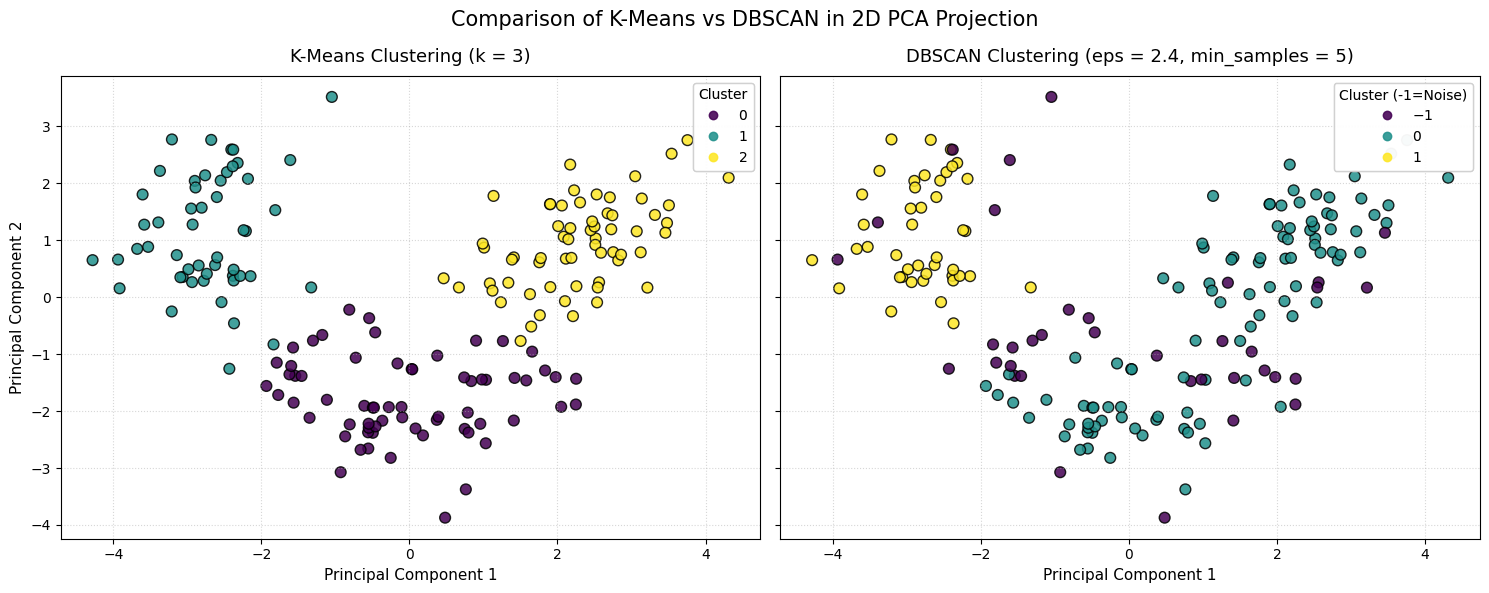

In [ ]:
# 2D PCA Visualizations

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

# K-Means Scatter Plot
scatter_km = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    edgecolor='k',
    s=60,
    alpha=0.85,
)
axes[0].set_title(f'K-Means Clustering (k = {elbow_k})', fontsize=13, pad=10)
axes[0].set_xlabel('Principal Component 1', fontsize=11)
axes[0].set_ylabel('Principal Component 2', fontsize=11)
legend_km = axes[0].legend(
    *scatter_km.legend_elements(), title='Cluster', loc='upper right'
)
axes[0].add_artist(legend_km)
axes[0].grid(True, linestyle=':', alpha=0.5)

# DBSCAN Scatter Plot
scatter_db = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap='viridis',
    edgecolor='k',
    s=60,
    alpha=0.85,
)
axes[1].set_title(
    f'DBSCAN Clustering (eps = {eps}, min_samples = {min_samples})',
    fontsize=13,
    pad=10,
)
axes[1].set_xlabel('Principal Component 1', fontsize=11)
legend_db = axes[1].legend(
    *scatter_db.legend_elements(), title='Cluster (-1=Noise)', loc='upper right'
)
axes[1].add_artist(legend_db)
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.suptitle(
    'Comparison of K-Means vs DBSCAN in 2D PCA Projection', fontsize=15, y=0.98
)
plt.tight_layout()
plt.show()

In [ ]:
# Inspect mean values across chemical variables to interpret cluster characteristics
profile_df = df.copy()
profile_df['KMeans_Cluster'] = kmeans_labels
cluster_means = profile_df.groupby('KMeans_Cluster').mean().T.round(2)
display(cluster_means)

KMeans_Cluster,0,1,2
Alcohol,12.25,13.13,13.68
Malic_Acid,1.90,3.31,2.00
Ash,2.23,2.42,2.47
Ash_Alcanity,20.06,21.24,17.46
Magnesium,92.74,98.67,107.97
Total_Phenols,2.25,1.68,2.85
Flavanoids,2.05,0.82,3.00
Nonflavanoid_Phenols,0.36,0.45,0.29
Proanthocyanins,1.62,1.15,1.92
Color_Intensity,2.97,7.23,5.45


What Each Cluster Represents

K-Means Clusters ($k=3$)

*   **Cluster 0: Light Table Wines (65 samples)**
This cluster represents light-bodied, approachable wines characterized by the lowest average alcohol content (12.25%) and softest color intensity (2.97). It is defined by low proline concentrations (510.17 mg/L) alongside moderate flavanoids, gathering distinctly in the upper-left quadrant of the PCA plot.
*   **Cluster 1: High-Acid, Astringent Wines (51 samples)** This group captures tart, deeply pigmented wines marked by the highest malic acid levels (3.31 g/L) and darkest color intensity (7.23). Its low flavanoid levels (0.82) and reduced protein dilution ratio point to astringent profiles that cluster across the lower-middle and right PCA regions.
*   **Cluster 2: Premium, Full-Bodied Wines (62 samples)** This cluster represents rich, concentrated wines with the highest alcohol content (13.68%), total phenols (2.85), and flavanoids (3.00). Its defining feature is a high proline concentration (1100.23 mg/L)—over double that of the other groups—forming a tight grouping in the upper-right PCA quadrant.


DBSCAN Clusters ($\varepsilon = 2.4$, min_samples $= 5$)

*   **Cluster 0: Broad Phenolic Core (99 samples)** DBSCAN merges 42 light wines from K-Means Cluster 0 and 57 full-bodied wines from K-Means Cluster 2 into one continuous cluster. Because these samples share an unbroken high-density corridor in 13-dimensional space without an empty valley between them, DBSCAN treats them as a single connected wine population.
*   **Cluster 1: Dense High-Acid Pocket (43 samples)** This cluster isolates 43 of the 51 high-acid wines belonging to K-Means Cluster 1 into an independent dense region. Their distinct chemical profile—extreme malic acid and depleted flavanoids—places them in a separated pocket of feature space that DBSCAN readily distinguishes from the main body.
*   **Noise Partition / Label -1: Diffuse Outliers (36 samples)** DBSCAN labels 36 samples (20.2% of the dataset) as noise because they do not have at least 5 neighbors within a radius of $\varepsilon = 2.4$. Rather than forcing these borderline or sparsely distributed wines into rigid centroids, DBSCAN leaves them unassigned to maintain high cluster density.







